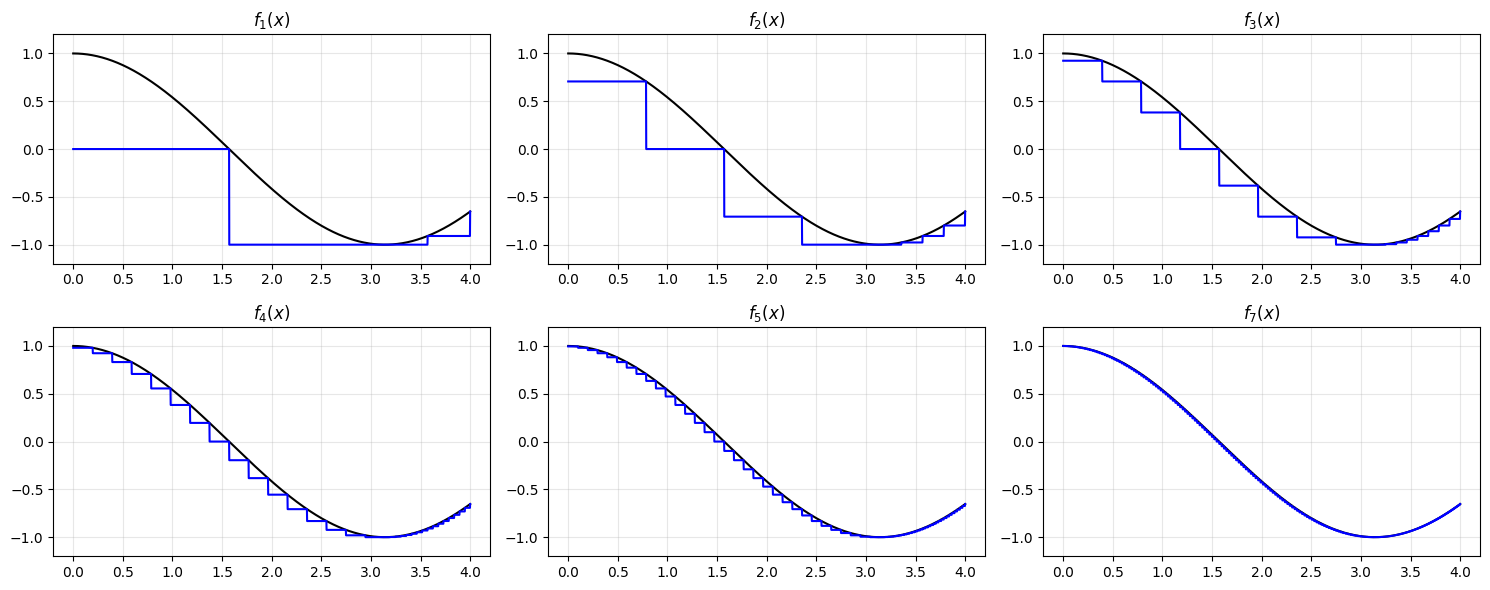

,n,Lebesgue integral,Lebesgue integral error,"Lebesgue time, sec",Lebesgue-Stieltjes integral,Lebesgue-Stieltjes error,"Lebesgue-Stieltjes time, sec"
0,1,-2.390274,1.633471,0.000017,-4.653644,3.344882,0.000044
1,2,-1.576458,0.819656,0.000036,-2.923598,1.614837,0.000028
2,3,-1.167357,0.410555,0.000020,-2.219595,0.910834,0.000037
3,4,-0.962262,0.205459,0.000035,-1.794380,0.485619,0.000070
4,5,-0.859577,0.102775,0.000075,-1.593452,0.284691,0.000135
5,7,-0.782505,0.025702,0.000278,-1.360530,0.051769,0.000617
6,10,-0.760016,0.003213,0.002142,-1.309908,0.001147,0.004441
7,15,-0.756903,0.000100,0.073287,-1.308930,0.000169,0.137890
8,20,-0.756806,0.000003,2.272358,-1.308771,0.000010,4.319181


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Вычисление функции cos(x)
def f(x):
    return np.cos(x)

# Вычисление функции fn(x)
def fn(n, x):
    if x < 0 or x > 4:
        return 0
    
    pow2 = 2**n 

    # Значение функции на [0, pi)
    if x < np.pi:
        k = int(x * pow2 / np.pi) + 1
        return f(k * np.pi / pow2)

    # Значение функции на [pi, 4)
    else: 
        length = 4 - np.pi
        k = int((x - np.pi) * pow2 / length) + 1
        return f(np.pi + ((k - 1) * length / pow2))
    
# Мера Лебега полуинтервала [a, b) 
def leb(a, b):
    return b - a

# Мера Лебега в точке {a}
def leb_point(a):
    return 0

# Мера Лебега-Стильтьеса полуинтервала [a, b) 
def leb_st(a, b):
    return np.ceil(2 * b) - np.ceil(2 * a)

# Мера Лебега-Стильтьеса в точке {a}
def leb_st_point(a):
    # Если 2 * a - целое, то мера = 1. Иначе 0
    if abs(2 * a - int(2 * a)) < 1e-12:
        return 1
    return 0

# Численное вычисление интеграла f(x) на [0, 4] по мере mu с помощью fn(x)
def integral(n, mu, mu_point):
    pow2 = 2**n

    # Вычисляем f+
    int_f_plus = 0.0
    seg_len = np.pi / pow2
    seg_l = 0
    seg_r = seg_len
    # Проходимся по ячейкам, прибавляя к результату значение простой функции,
    # умноженное на меру ячейки
    for _ in range(1, pow2 + 1):
        int_f_plus += fn(n, (seg_r + seg_l) / 2) * mu(seg_l, seg_r)
        seg_l = seg_r
        seg_r = min(seg_r + seg_len, np.pi)

    # Вычисляем f-
    int_f_minus = 0.0
    seg_len = (4 - np.pi) / pow2
    seg_l = np.pi
    seg_r = np.pi + seg_len
    # Проходимся по ячейкам, отнимая от результата значение простой функции,
    # умноженное на меру ячейки
    for _ in range(1, pow2 + 1):
        int_f_minus -= fn(n, (seg_r + seg_l) / 2) * mu(seg_l, seg_r)
        seg_l = seg_r
        seg_r = min(seg_r + seg_len, 4.0)
    
    # Добавляем значение в точке {4}
    int_f_minus -= fn(n, 4.0) * mu_point(4.0)

    # Интеграл от f = Интаграл от f+ - Интаграл от f-
    return int_f_plus - int_f_minus

# Функция построения графиков для n = 1, 2, 3, 4, 5, 7
def graphs(n_vals):
    x = np.linspace(0, 4, 2000)
    _, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(6):
        y = [fn(n_vals[i], xi) for xi in x]
        axes[i].set_title(rf'$f_{n_vals[i]}(x)$')
        axes[i].plot(x, f(x), 'k')
        axes[i].plot(x, y, 'b')
        axes[i].set_ylim(-1.2, 1.2)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Функция построения таблицы с вычисленными интегралами, 
# сравнением с аналитическим результатом и временем вычисления
# в зависимости от n
def tabulate(n_vals):
    exact_leb = np.sin(4)
    exact_leb_st = sum(f(k/2) for k in range(9)) 
    data = []
    for n in n_vals:
        start_time = time.perf_counter()
        int_leb = integral(n, leb, leb_point)
        time_leb = time.perf_counter() - start_time

        start_time = time.perf_counter()
        int_st = integral(n, leb_st, leb_st_point)
        time_st = time.perf_counter() - start_time

        data.append({
            'n': n,
            'Lebesgue integral': int_leb,
            'Lebesgue integral error': abs(int_leb - exact_leb),
            'Lebesgue time, sec': time_leb,
            'Lebesgue-Stieltjes integral': int_st,
            'Lebesgue-Stieltjes error': abs(int_st - exact_leb_st),
            'Lebesgue-Stieltjes time, sec': time_st
        })

    df = pd.DataFrame(data)
    display(df)

n_vals = [1, 2, 3, 4, 5, 7, 10, 15, 20]
graphs(n_vals)
tabulate(n_vals)
